# ADTK Outlier Detection
Outlier detection exploration using different `adtk` models on unevenly spaced seasonal time series data

## Dependencies:
- matplotlib
- pandas
- seaborn
- time_series_generator

`adtk` main branch is outdated, use this fork:  https://github.com/HazmanNaim/improved-adtk

### Notes:
- Doing two seasons with `time_series_generator.create_time_series` breaks `adtk.SeasonalAD`
- Could have multi-variate data (i.e. detections from >1 source) and use OrAggregate/AndAggregate to analyze anomaly outcome of each source as compared to another
- `adtk.pipe` can chain components together in series (and visualize the pipeline), e.g. connect `ClassicalSeasonalDecomposition` transformer with `QuantileAD` detector
- DONT use interpolated data for IQR, undecided for Quantile & GeneralizedESDTest
- AutoRegressive and Persist are trash

In [ ]:
from utils.time_series_generator import create_time_series
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

--- 
#### Generate synthetic data

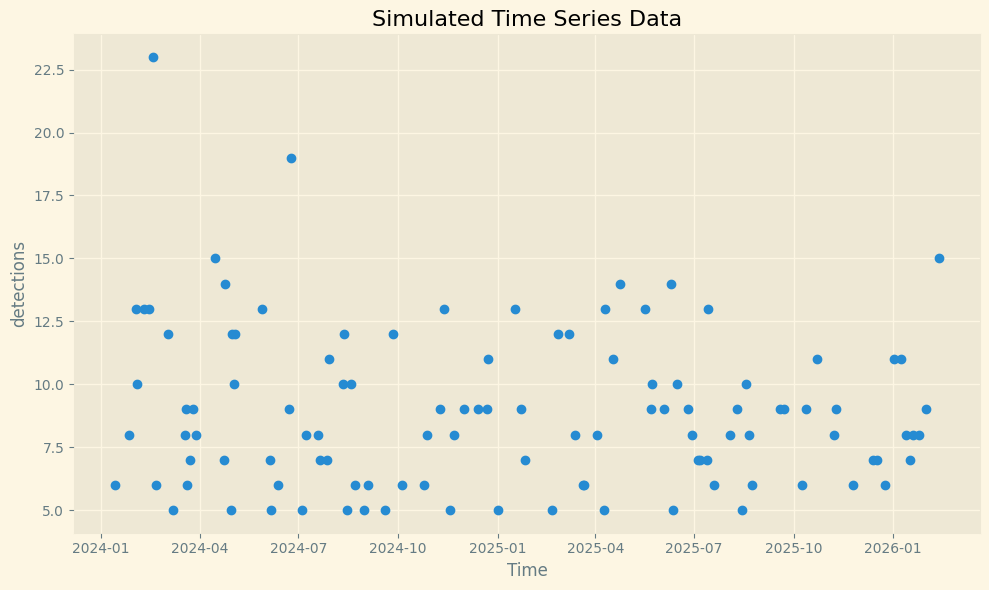

In [59]:
# Create unevenly spaced seasonal time series data
seed = int(time.time_ns())
data = create_time_series(
    start_date="2024-01-01",
    magnitude=5,
    floor=5,
    log_rate=0.25,
    seasonal_cycles={7: 0.01, 365.25: 0.001},
    seed = seed,
    y_label="detections",
    plot=True,
)

In [60]:
len(data)

109

---
### adtk data processing 

In [61]:
from adtk.data import validate_series
from adtk.visualization import plot

In [62]:
s_raw = (
    data
    .set_index("time")
    ["detections"]
    .astype(float)
)
s_raw.index = pd.DatetimeIndex(s_raw.index)
real_index = s_raw.index  # store the original dates before reindexing

In [63]:
full_index = pd.date_range(s_raw.index.min(), s_raw.index.max(), freq="D")
s = (
    s_raw
    .reindex(full_index)
    .interpolate(method="time")
    .ffill()
)

In [64]:
s = validate_series(s).ffill()

In [65]:
s.isna().sum()

np.int64(0)

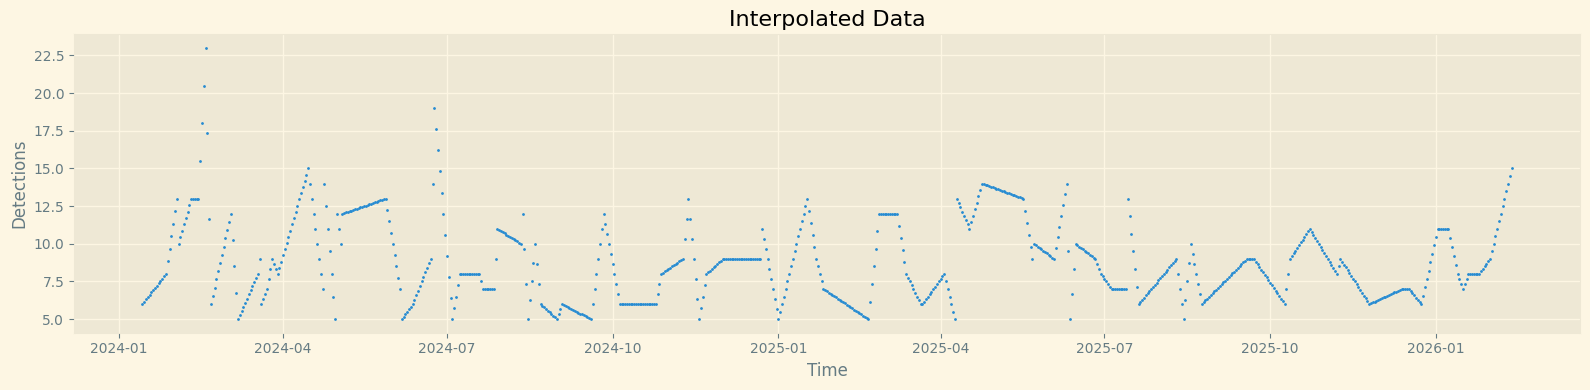

In [66]:
plt.figure(figsize=(16, 4))
plt.plot(s.index, s.values, ".", markersize=2)
plt.title("Interpolated Data")
plt.xlabel("Time")
plt.ylabel("Detections")
plt.tight_layout()
plt.show()

--- 
#### SeasonalAD detections

In [67]:
from adtk.detector import SeasonalAD

In [68]:
seasonal_ad = SeasonalAD(freq=7)
s_anomalies = seasonal_ad.fit_detect(s)
s_anomalies = s_anomalies[s_anomalies.index.isin(real_index) & s_anomalies.astype(bool)]

2026-02-28 11:43:22,741 - adtk.detector._detector_1d - INFO - IQRAD initialized with lower_factor=None, upper_factor=3.0
2026-02-28 11:43:22,742 - adtk.detector._detector_1d - INFO - IQRAD fitting started: 761 non-null points
2026-02-28 11:43:22,743 - adtk.detector._detector_1d - INFO - Computed quartiles: Q1=0.8888, Q3=2.9255, IQR=2.0367
2026-02-28 11:43:22,743 - adtk.detector._detector_1d - INFO - IQRAD Thresholds set: abs_low_=-inf, abs_high_=9.0355
2026-02-28 11:43:22,744 - adtk.detector._detector_1d - INFO - ThresholdAD initialized with low=inf, high=-inf
2026-02-28 11:43:22,745 - adtk.detector._detector_1d - INFO - ThresholdAD prediction started on series of length 761
2026-02-28 11:43:22,745 - adtk.detector._detector_1d - INFO - High threshold -inf applied: 761/761 points above
2026-02-28 11:43:22,745 - adtk.detector._detector_1d - INFO - Low threshold inf applied: 761/761 points below
2026-02-28 11:43:22,746 - adtk.detector._detector_1d - INFO - ThresholdAD prediction completed

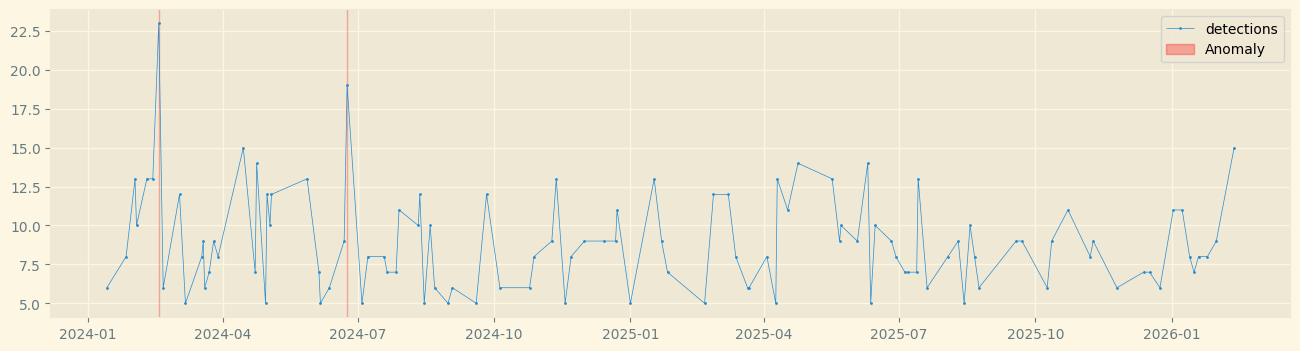

In [69]:
if not s_anomalies.empty:
    s_anomalies.index.freq = None
    plot(
        ts=s_raw,
        anomaly=s_anomalies,
        anomaly_tag="span",
        anomaly_color="red",
        figsize=(16, 4),
    )

In [70]:
print(s_anomalies.value_counts())

detections
1.0    2
Name: count, dtype: int64


---
### AutoregressionAD detections

In [71]:
from adtk.detector import AutoregressionAD

In [72]:
autoregression_ad = AutoregressionAD(n_steps=2, step_size=3)
ar_anomalies = autoregression_ad.fit_detect(s)
ar_anomalies = ar_anomalies[ar_anomalies.index.isin(real_index) & ar_anomalies.astype(bool)]

2026-02-28 11:43:22,897 - adtk.detector._detector_1d - INFO - IQRAD initialized with lower_factor=None, upper_factor=3.0
2026-02-28 11:43:22,897 - adtk.detector._detector_1d - INFO - IQRAD fitting started: 755 non-null points
2026-02-28 11:43:22,898 - adtk.detector._detector_1d - INFO - Computed quartiles: Q1=0.3187, Q3=1.4686, IQR=1.1499
2026-02-28 11:43:22,899 - adtk.detector._detector_1d - INFO - IQRAD Thresholds set: abs_low_=-inf, abs_high_=4.9183
2026-02-28 11:43:22,904 - adtk.detector._detector_1d - INFO - ThresholdAD initialized with low=inf, high=-inf
2026-02-28 11:43:22,905 - adtk.detector._detector_1d - INFO - ThresholdAD prediction started on series of length 761
2026-02-28 11:43:22,905 - adtk.detector._detector_1d - INFO - High threshold -inf applied: 755/761 points above
2026-02-28 11:43:22,906 - adtk.detector._detector_1d - INFO - Low threshold inf applied: 755/761 points below
2026-02-28 11:43:22,906 - adtk.detector._detector_1d - INFO - ThresholdAD prediction completed

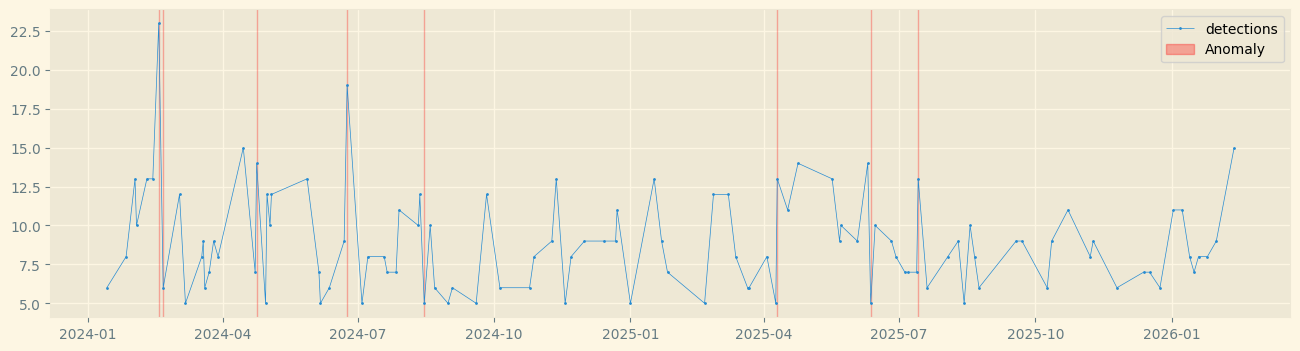

In [73]:
if not ar_anomalies.empty:
    ar_anomalies.index.freq = None
    plot(
        ts=s_raw,
        anomaly=ar_anomalies,
        anomaly_tag="span",
        anomaly_color="red",
        figsize=(16, 4),
    )

In [74]:
print(ar_anomalies.value_counts())

detections
1.0    8
Name: count, dtype: int64


--- 
### QuantileAD detections (interpolated)

In [75]:
from adtk.detector import QuantileAD

In [76]:
quantile_ad = QuantileAD(high=0.99, low=0.01)
q_anomalies = quantile_ad.fit_detect(s)
q_anomalies = q_anomalies[q_anomalies.index.isin(real_index) & q_anomalies.astype(bool)]

2026-02-28 11:43:23,057 - adtk.detector._detector_1d - INFO - QuantileAD initialized with low_quantile=0.01, high_quantile=0.99
2026-02-28 11:43:23,058 - adtk.detector._detector_1d - INFO - QuantileAD fitting started: 761 non-null points
2026-02-28 11:43:23,059 - adtk.detector._detector_1d - INFO - Fitted low quantile (0.01): 5.0000
2026-02-28 11:43:23,060 - adtk.detector._detector_1d - INFO - Fitted high quantile (0.99): 15.2000
2026-02-28 11:43:23,060 - adtk.detector._detector_1d - INFO - QuantileAD prediction started on series of length 761
2026-02-28 11:43:23,060 - adtk.detector._detector_1d - INFO - High quantile threshold 15.2000: 8/761 points above
2026-02-28 11:43:23,061 - adtk.detector._detector_1d - INFO - Low quantile threshold 5.0000: 0/761 points below
2026-02-28 11:43:23,062 - adtk.detector._detector_1d - INFO - QuantileAD prediction completed: 8 anomalies detected


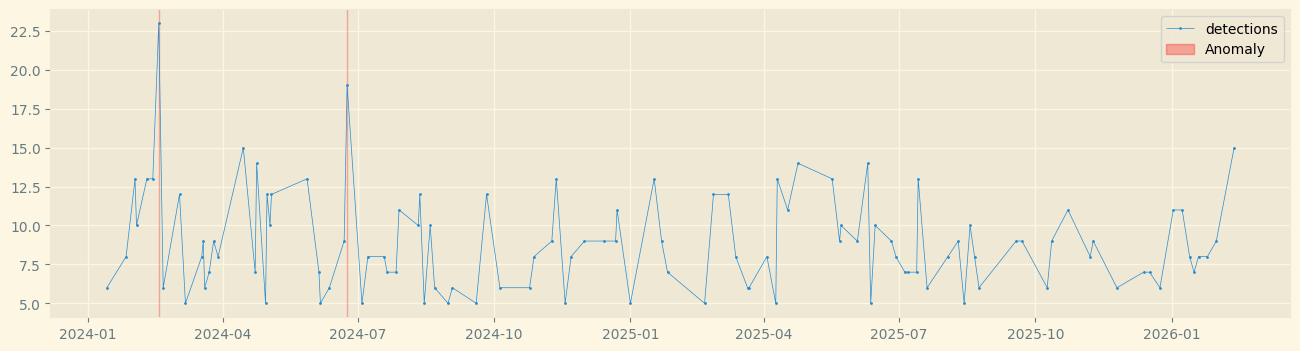

In [77]:
if not q_anomalies.empty:
    q_anomalies.index.freq = None
    plot(
        ts=s_raw,
        anomaly=q_anomalies,
        anomaly_tag="span",
        anomaly_color="red",
        figsize=(16, 4),
)

In [78]:
print(q_anomalies.value_counts())

detections
1.0    2
Name: count, dtype: int64


--- 
### QuantileAD detections (raw)

In [79]:
q2_anomalies = quantile_ad.fit_detect(s_raw)
q2_anomalies = q2_anomalies[q2_anomalies.astype(bool)]

2026-02-28 11:43:23,213 - adtk.detector._detector_1d - INFO - QuantileAD initialized with low_quantile=0.01, high_quantile=0.99
2026-02-28 11:43:23,213 - adtk.detector._detector_1d - INFO - QuantileAD fitting started: 109 non-null points
2026-02-28 11:43:23,214 - adtk.detector._detector_1d - INFO - Fitted low quantile (0.01): 5.0000
2026-02-28 11:43:23,215 - adtk.detector._detector_1d - INFO - Fitted high quantile (0.99): 18.6800
2026-02-28 11:43:23,215 - adtk.detector._detector_1d - INFO - QuantileAD prediction started on series of length 109
2026-02-28 11:43:23,216 - adtk.detector._detector_1d - INFO - High quantile threshold 18.6800: 2/109 points above
2026-02-28 11:43:23,216 - adtk.detector._detector_1d - INFO - Low quantile threshold 5.0000: 0/109 points below
2026-02-28 11:43:23,217 - adtk.detector._detector_1d - INFO - QuantileAD prediction completed: 2 anomalies detected


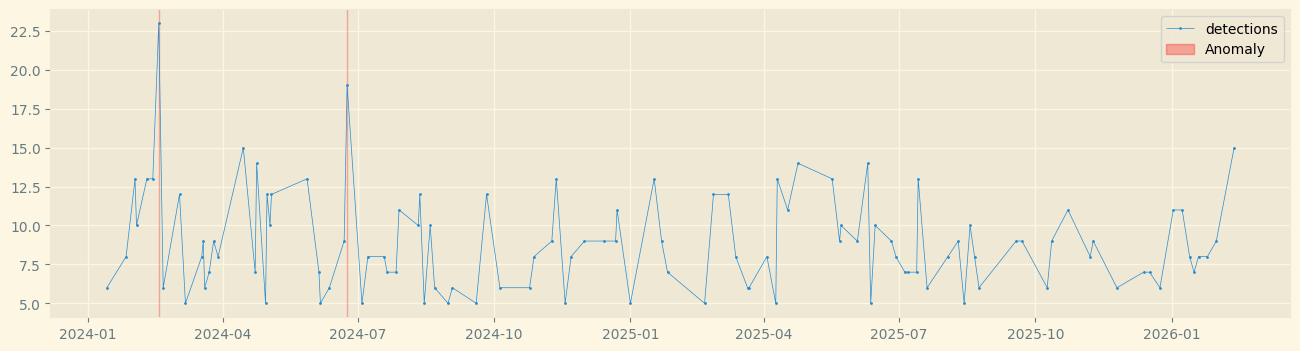

In [80]:
if not q2_anomalies.empty:
    q2_anomalies.index.freq = None
    plot(
        ts=s_raw,
        anomaly=q2_anomalies,
        anomaly_tag="span",
        anomaly_color="red",
        figsize=(16, 4),
    )

In [81]:
print(q2_anomalies.value_counts())

detections
1.0    2
Name: count, dtype: int64


--- 
### InterQuartileRangeAD detections (interpolated)

In [82]:
from adtk.detector import InterQuartileRangeAD

In [83]:
interquartilerange_ad = InterQuartileRangeAD(c=1.5)
iqr_anomalies = interquartilerange_ad.fit_detect(s)
iqr_anomalies = iqr_anomalies[iqr_anomalies.index.isin(real_index) & iqr_anomalies.astype(bool)]

2026-02-28 11:43:23,356 - adtk.detector._detector_1d - INFO - IQRAD initialized with symmetric factor=1.50
2026-02-28 11:43:23,357 - adtk.detector._detector_1d - INFO - IQRAD fitting started: 761 non-null points
2026-02-28 11:43:23,358 - adtk.detector._detector_1d - INFO - Computed quartiles: Q1=6.8571, Q3=10.4545, IQR=3.5974
2026-02-28 11:43:23,359 - adtk.detector._detector_1d - INFO - IQRAD Thresholds set: abs_low_=1.4610, abs_high_=15.8506
2026-02-28 11:43:23,359 - adtk.detector._detector_1d - INFO - IQRAD prediction started on series of length 761
2026-02-28 11:43:23,359 - adtk.detector._detector_1d - INFO - High IQR threshold 15.8506: 7/761 above
2026-02-28 11:43:23,360 - adtk.detector._detector_1d - INFO - Low IQR threshold 1.4610: 0/761 below
2026-02-28 11:43:23,361 - adtk.detector._detector_1d - INFO - IQRAD prediction complete: 7 anomalies detected


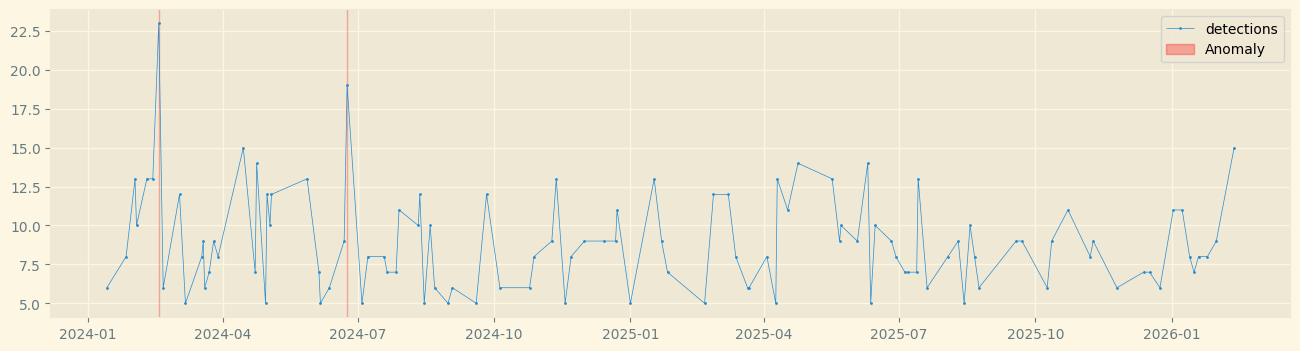

In [84]:
if not iqr_anomalies.empty:
    iqr_anomalies.index.freq = None
    plot(
        ts=s_raw,
        anomaly=iqr_anomalies,
        anomaly_tag="span",
        anomaly_color="red",
        figsize=(16, 4),
    )

In [85]:
print(iqr_anomalies.value_counts())

detections
1.0    2
Name: count, dtype: int64


---  
### InterQuartileRangeAD detections (raw)

In [86]:
iqr2_anomalies = interquartilerange_ad.fit_detect(s_raw)
iqr2_anomalies = iqr2_anomalies[iqr2_anomalies.astype(bool)]

2026-02-28 11:43:23,496 - adtk.detector._detector_1d - INFO - IQRAD initialized with symmetric factor=1.50
2026-02-28 11:43:23,496 - adtk.detector._detector_1d - INFO - IQRAD fitting started: 109 non-null points
2026-02-28 11:43:23,498 - adtk.detector._detector_1d - INFO - Computed quartiles: Q1=6.0000, Q3=11.0000, IQR=5.0000
2026-02-28 11:43:23,498 - adtk.detector._detector_1d - INFO - IQRAD Thresholds set: abs_low_=-1.5000, abs_high_=18.5000
2026-02-28 11:43:23,499 - adtk.detector._detector_1d - INFO - IQRAD prediction started on series of length 109
2026-02-28 11:43:23,499 - adtk.detector._detector_1d - INFO - High IQR threshold 18.5000: 2/109 above
2026-02-28 11:43:23,499 - adtk.detector._detector_1d - INFO - Low IQR threshold -1.5000: 0/109 below
2026-02-28 11:43:23,500 - adtk.detector._detector_1d - INFO - IQRAD prediction complete: 2 anomalies detected


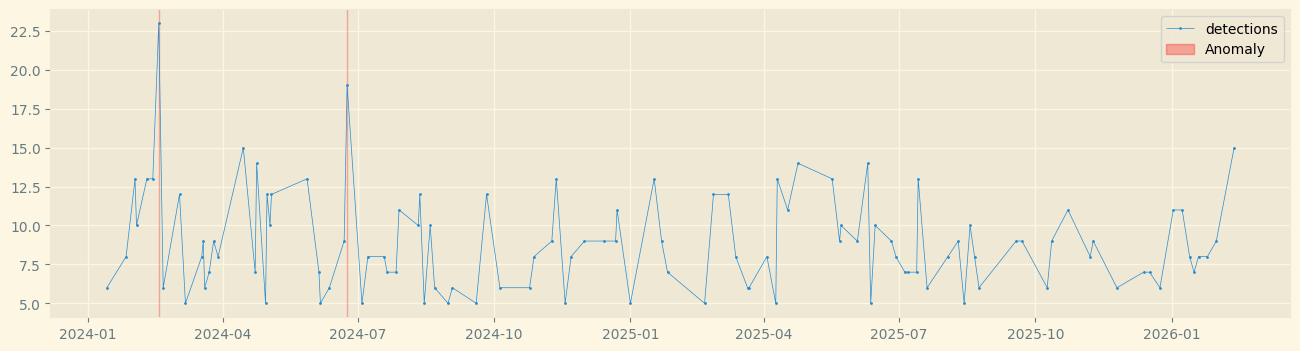

In [87]:
if not iqr2_anomalies.empty:
    iqr2_anomalies.index.freq = None
    plot(
        ts=s_raw,
        anomaly=iqr2_anomalies,
        anomaly_tag="span",
        anomaly_color="red",
        figsize=(16, 4),
    )

In [88]:
print(iqr2_anomalies.value_counts())

detections
1.0    2
Name: count, dtype: int64


---  
### GeneralizedESDTestAD detections (interpolated)

**NOTE:**  A key assumption of generalized ESD test is that normal values follow an approximately normal distribution. Use this detector when this assumption holds.

In [89]:
from adtk.detector import GeneralizedESDTestAD

In [90]:
esd_ad = GeneralizedESDTestAD(alpha=0.3)
esd_anomalies = esd_ad.fit_detect(s)
esd_anomalies = esd_anomalies[esd_anomalies.index.isin(real_index) & esd_anomalies.astype(bool)]

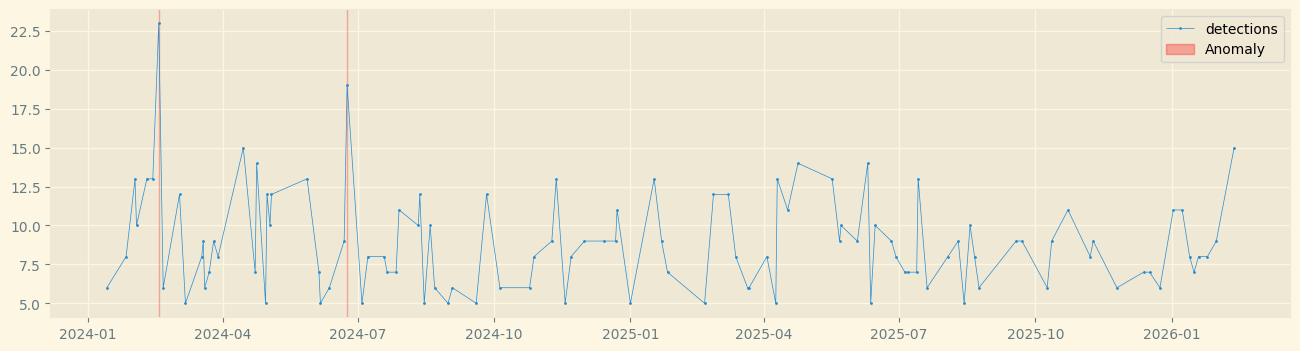

In [91]:
if not esd_anomalies.empty:
    esd_anomalies.index.freq = None
    plot(
        ts=s_raw,
        anomaly=esd_anomalies,
        anomaly_tag="span",
        anomaly_color="red",
        figsize=(16, 4),
    )

In [92]:
print(esd_anomalies.value_counts())

detections
True    2
Name: count, dtype: int64


---  
### GeneralizedESDTestAD detections (raw)

**NOTE:**  A key assumption of generalized ESD test is that normal values follow an approximately normal distribution. Use this detector when this assumption holds.

In [93]:
esd2_anomalies = esd_ad.fit_detect(s_raw)
esd2_anomalies = esd2_anomalies[esd2_anomalies.astype(bool)]

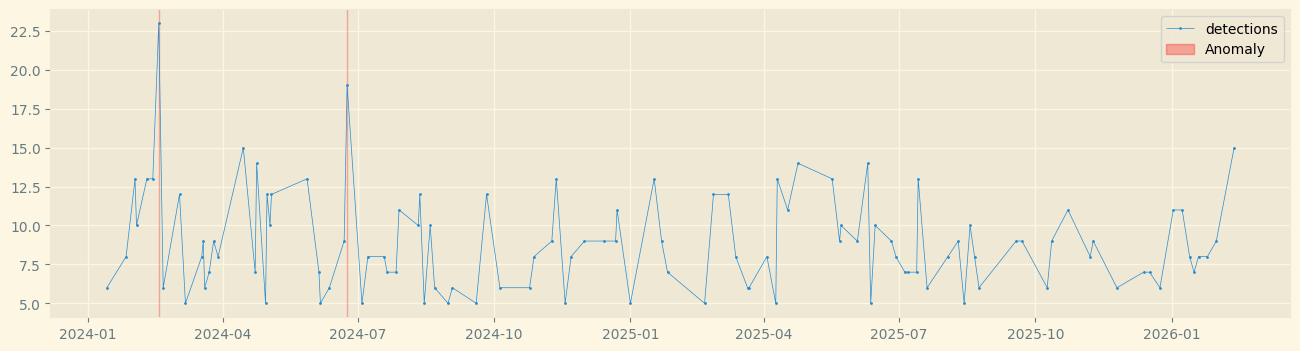

In [94]:
if not esd2_anomalies.empty:
    esd2_anomalies.index.freq = None
    plot(
        ts=s_raw,
        anomaly=esd2_anomalies,
        anomaly_tag="span",
        anomaly_color="red",
        figsize=(16, 4),
    )

In [95]:
print(esd2_anomalies.value_counts())

detections
True    2
Name: count, dtype: int64


---  
### PersistAD detections (interpolated)

In [96]:
from adtk.detector import PersistAD

In [97]:
persist_ad = PersistAD(c=3.0, side='positive')
p_anomalies = persist_ad.fit_detect(s)
p_anomalies = p_anomalies[p_anomalies.index.isin(real_index) & p_anomalies.astype(bool)]

2026-02-28 11:43:23,926 - adtk.detector._detector_1d - INFO - Initialized PersistAD with parameters: window=1, c=3.00, side='positive', min_periods=None, agg='median'
2026-02-28 11:43:23,926 - adtk.detector._detector_1d - INFO - Fitting PersistAD on series with 761 points.
2026-02-28 11:43:23,927 - adtk.transformer._transformer_1d - INFO - DoubleRollingAggregate initialized with window=(1, 1), agg=median, agg_params=None, center=True, min_periods=(None, 1), diff=l1
2026-02-28 11:43:23,927 - adtk.transformer._transformer_1d - INFO - Starting DoubleRollingAggregate prediction on series of length 761
2026-02-28 11:43:23,927 - adtk.transformer._transformer_1d - INFO - Normalized parameters: left_window=1, right_window=1, min_periods=(None, 1), agg=('median', 'median')
2026-02-28 11:43:23,930 - adtk.transformer._transformer_1d - INFO - Center=True: shifted left by 1, reversed right computation
2026-02-28 11:43:23,930 - adtk.transformer._transformer_1d - INFO - Aggregated windows: left_NaNs=

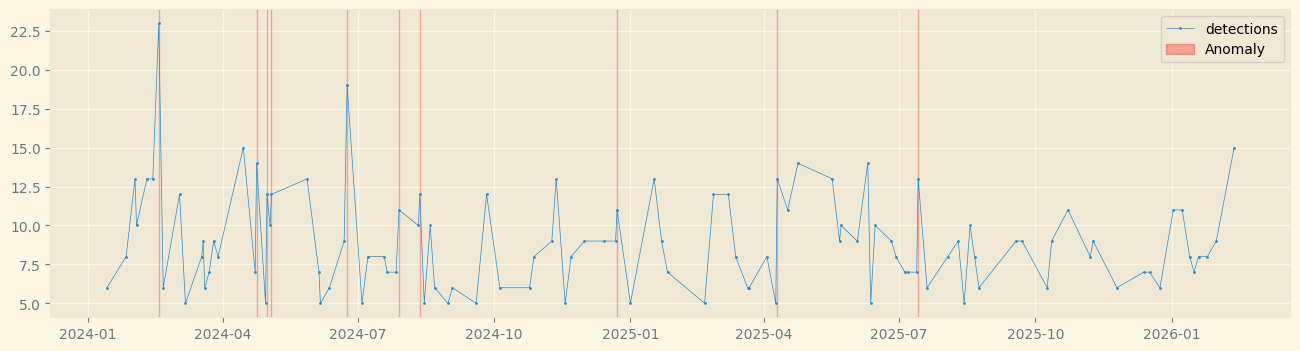

In [98]:
if not p_anomalies.empty:
    plot(
        ts=s_raw,
        anomaly=p_anomalies,
        anomaly_tag="span",
        anomaly_color="red",
        figsize=(16, 4),
)

In [99]:
print(p_anomalies.value_counts())

detections
1.0    10
Name: count, dtype: int64


---  
### PersistAD detections (raw)

In [100]:
p2_anomalies = persist_ad.fit_detect(s_raw)
p2_anomalies = p2_anomalies[p2_anomalies.index.isin(real_index) & p2_anomalies.astype(bool)]

2026-02-28 11:43:24,092 - adtk.detector._detector_1d - INFO - Initialized PersistAD with parameters: window=1, c=3.00, side='positive', min_periods=None, agg='median'
2026-02-28 11:43:24,092 - adtk.detector._detector_1d - INFO - Fitting PersistAD on series with 109 points.
2026-02-28 11:43:24,093 - adtk.transformer._transformer_1d - INFO - DoubleRollingAggregate initialized with window=(1, 1), agg=median, agg_params=None, center=True, min_periods=(None, 1), diff=l1
2026-02-28 11:43:24,093 - adtk.transformer._transformer_1d - INFO - Starting DoubleRollingAggregate prediction on series of length 109
2026-02-28 11:43:24,093 - adtk.transformer._transformer_1d - INFO - Normalized parameters: left_window=1, right_window=1, min_periods=(None, 1), agg=('median', 'median')
2026-02-28 11:43:24,095 - adtk.transformer._transformer_1d - INFO - Center=True: shifted left by 1, reversed right computation
2026-02-28 11:43:24,095 - adtk.transformer._transformer_1d - INFO - Aggregated windows: left_NaNs=

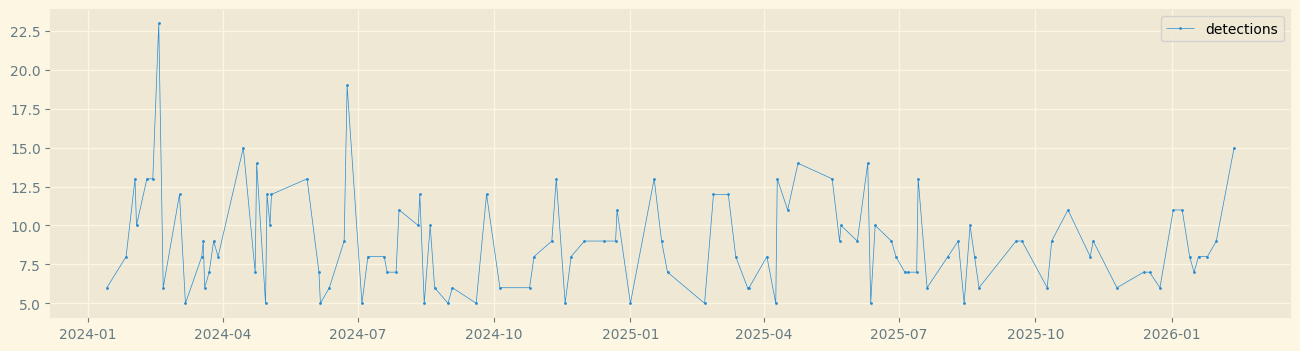

In [101]:
if not p2_anomalies.empty:
    p2_anomalies.index.freq = None
    plot(
        ts=s_raw,
        anomaly=p2_anomalies,
        anomaly_tag="span",
        anomaly_color="red",
        figsize=(16, 4),
    )

In [102]:
print(p2_anomalies.value_counts())

Series([], Name: count, dtype: int64)


---
# Outlier Detection Metrics

In [103]:
anomaly_series = {
    "SeasonalAD": s_anomalies,
    "AutoregressionAD": ar_anomalies,
    "QuantileAD (interp)": q_anomalies,
    "QuantileAD (raw)": q2_anomalies,
    "IQR (interp)": iqr_anomalies,
    "IQR (raw)": iqr2_anomalies,
    "ESD (interp)": esd_anomalies,
    "ESD (raw)": esd2_anomalies,
    "PersistAD (interp)": p_anomalies,
    "PersistAD (raw)": p2_anomalies,
}

counts = pd.Series({name: len(s) for name, s in anomaly_series.items()}, name="anomaly_count")
print(counts)

SeasonalAD              2
AutoregressionAD        9
QuantileAD (interp)     2
QuantileAD (raw)        2
IQR (interp)            2
IQR (raw)               2
ESD (interp)            2
ESD (raw)               2
PersistAD (interp)     11
PersistAD (raw)         1
Name: anomaly_count, dtype: int64


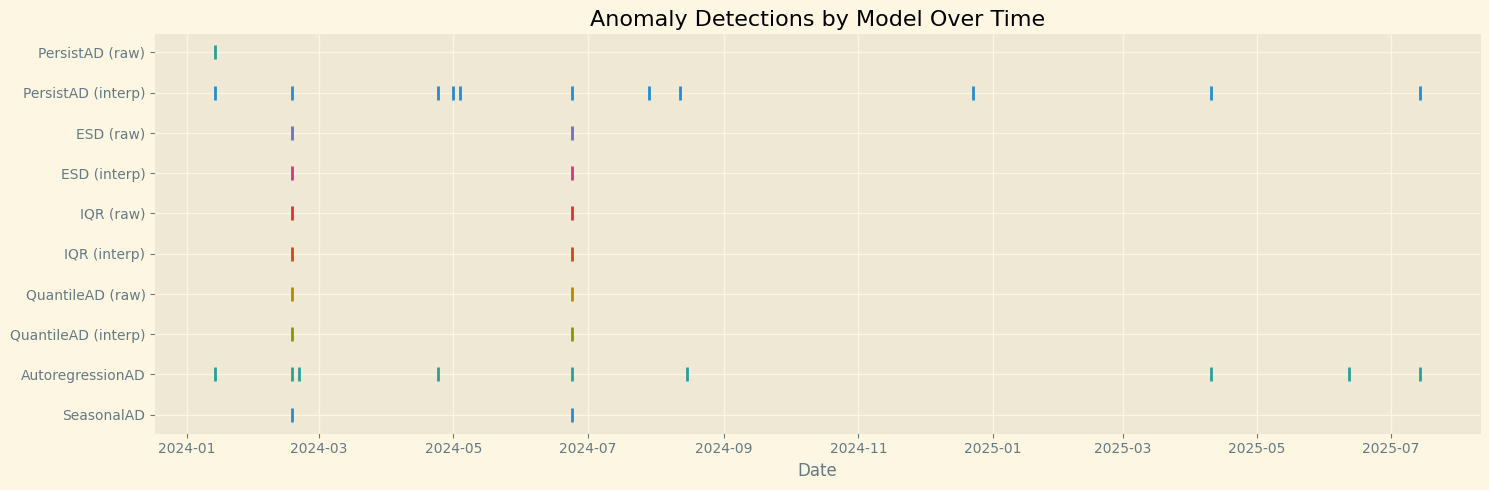

In [104]:
fig, ax = plt.subplots(figsize=(15, 5))

for i, (name, series) in enumerate(anomaly_series.items()):
    ax.scatter(series.index, [i] * len(series), marker="|", s=100, label=name)

ax.set_yticks(range(len(anomaly_series)))
ax.set_yticklabels(anomaly_series.keys())
ax.set_xlabel("Date")
ax.set_title("Anomaly Detections by Model Over Time")
plt.tight_layout()
plt.show()

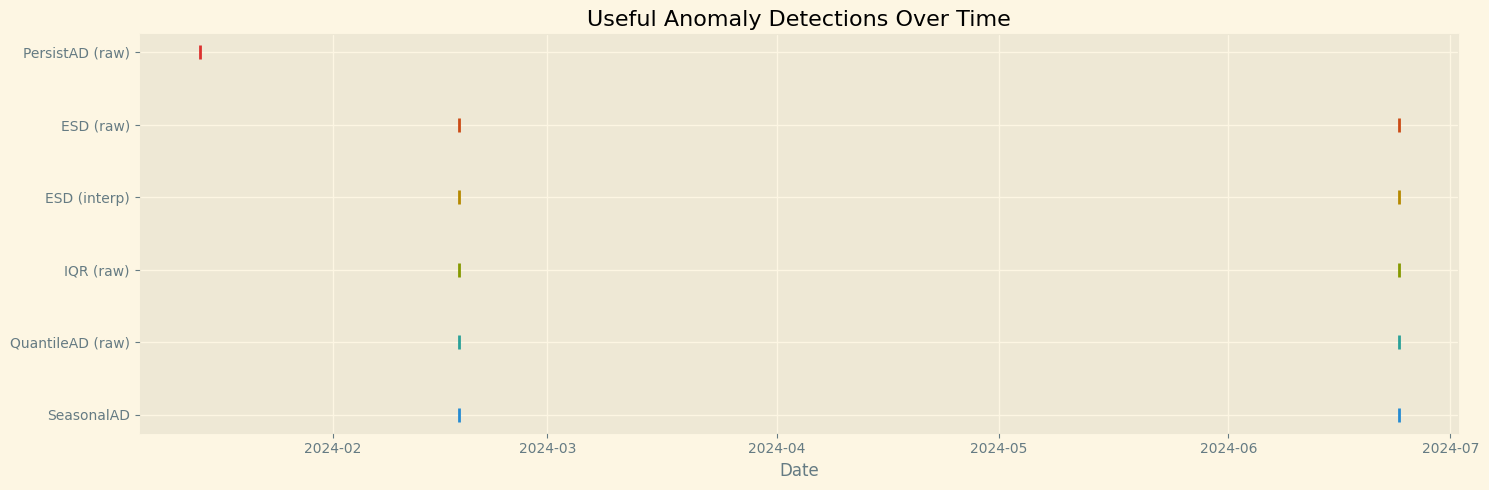

In [105]:
exclude = {"PersistAD (interp)", "IQR (interp)", "QuantileAD (interp)", "AutoregressionAD"}
filtered_series = {name: series for name, series in anomaly_series.items() if name not in exclude}

fig, ax = plt.subplots(figsize=(15, 5))

for i, (name, series) in enumerate(filtered_series.items()):
    ax.scatter(series.index, [i] * len(series), marker="|", s=100, label=name)

ax.set_yticks(range(len(filtered_series)))
ax.set_yticklabels(filtered_series.keys())
ax.set_xlabel("Date")
ax.set_title("Useful Anomaly Detections Over Time")
plt.tight_layout()
plt.show()

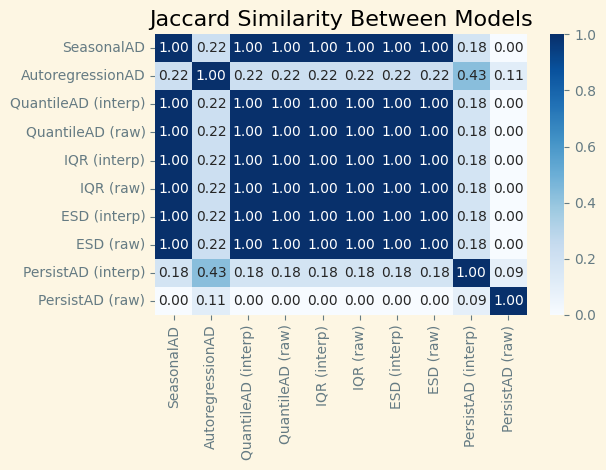

In [106]:
from itertools import combinations

names = list(anomaly_series.keys())
jaccard = pd.DataFrame(index=names, columns=names, dtype=float)

for a, b in combinations(names, 2):
    set_a = set(anomaly_series[a].index)
    set_b = set(anomaly_series[b].index)
    score = len(set_a & set_b) / len(set_a | set_b) if set_a | set_b else 0.0
    jaccard.loc[a, b] = score
    jaccard.loc[b, a] = score

for name in names:
    jaccard.loc[name, name] = 1.0

sns.heatmap(jaccard.astype(float), annot=True, fmt=".2f", cmap="Blues")
plt.title("Jaccard Similarity Between Models")
plt.tight_layout()
plt.show()

In [107]:
pairs = [
    ("QuantileAD (interp)", "QuantileAD (raw)", q_anomalies, q2_anomalies),
    ("IQR (interp)", "IQR (raw)", iqr_anomalies, iqr2_anomalies),
    ("ESD (interp)", "ESD (raw)", esd_anomalies, esd2_anomalies),
    ("PersistAD (interp)", "PersistAD (raw)", p_anomalies, p2_anomalies),
]

for name_a, name_b, a, b in pairs:
    a_dates = set(a.index)
    b_dates = set(b.index)
    print(f"\n{name_a} vs {name_b}")
    print(f"  Shared:            {len(a_dates & b_dates)}")
    print(f"  Only interpolated: {len(a_dates - b_dates)}")
    print(f"  Only raw:          {len(b_dates - a_dates)}")


QuantileAD (interp) vs QuantileAD (raw)
  Shared:            2
  Only interpolated: 0
  Only raw:          0

IQR (interp) vs IQR (raw)
  Shared:            2
  Only interpolated: 0
  Only raw:          0

ESD (interp) vs ESD (raw)
  Shared:            2
  Only interpolated: 0
  Only raw:          0

PersistAD (interp) vs PersistAD (raw)
  Shared:            1
  Only interpolated: 10
  Only raw:          0


In [108]:
all_flagged = sorted(set().union(*[set(s.index) for s in filtered_series.values()]))

agreement = pd.DataFrame({
    name: pd.Series(True, index=s.index).reindex(all_flagged).fillna(False).astype(int)
    for name, s in filtered_series.items()
}, index=all_flagged)

agreement["consensus"] = agreement.sum(axis=1)
high_confidence = agreement[agreement["consensus"] >= 3]

print(f"{len(high_confidence)} dates flagged by 3+ models\n")
for date, row in high_confidence.iterrows():
    models = [name for name in filtered_series.keys() if row[name] == 1]
    print(f"{date.date()}  (flagged by {int(row['consensus'])} models)")
    for m in models:
        print(f"  - {m}")

2 dates flagged by 3+ models

2024-02-18  (flagged by 5 models)
  - SeasonalAD
  - QuantileAD (raw)
  - IQR (raw)
  - ESD (interp)
  - ESD (raw)
2024-06-24  (flagged by 5 models)
  - SeasonalAD
  - QuantileAD (raw)
  - IQR (raw)
  - ESD (interp)
  - ESD (raw)


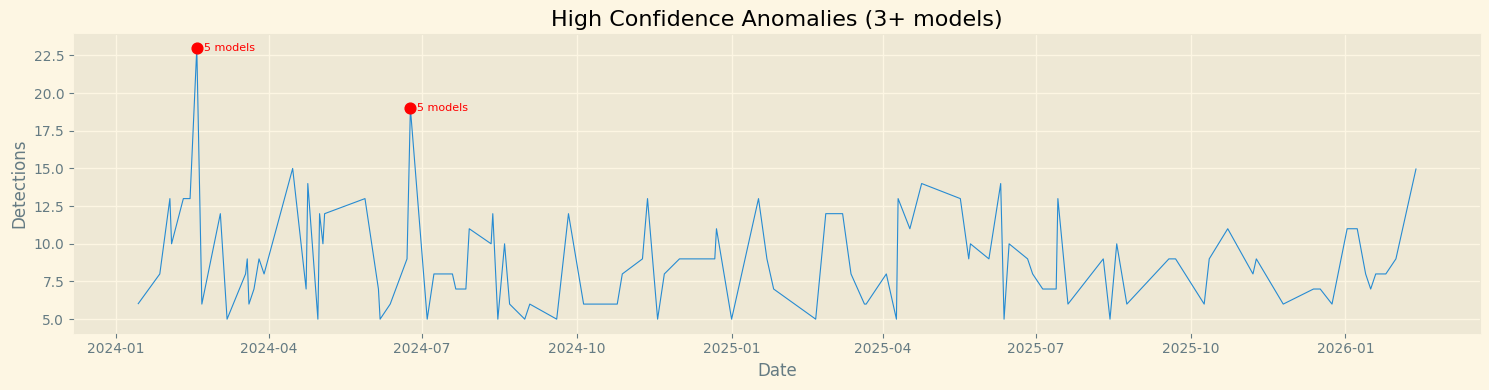

In [109]:
fig, ax = plt.subplots(figsize=(15, 4))

ax.plot(s_raw.index, s_raw.values, linewidth=0.8)

for date, row in high_confidence.iterrows():
    ax.scatter(date, s_raw.loc[date], color="red", s=60, zorder=5)
    ax.text(date, s_raw.loc[date], f"  {int(row['consensus'])} models",
            color="red", fontsize=8, va="center")

ax.set_title("High Confidence Anomalies (3+ models)")
ax.set_xlabel("Date")
ax.set_ylabel("Detections")
plt.tight_layout()
plt.show()

In [110]:
excluded_series = {name: series for name, series in anomaly_series.items() if name in exclude}

all_flagged = sorted(set().union(
    *[set(series.index) for series in anomaly_series.values()]
))

filtered_agreement = pd.DataFrame({
    name: pd.Series(True, index=series.index).reindex(all_flagged).fillna(False).astype(int)
    for name, series in filtered_series.items()
}, index=all_flagged)

excluded_agreement = pd.DataFrame({
    name: pd.Series(True, index=series.index).reindex(all_flagged).fillna(False).astype(int)
    for name, series in excluded_series.items()
}, index=all_flagged)

filtered_agreement["filtered_count"] = filtered_agreement.sum(axis=1)
excluded_agreement["excluded_count"] = excluded_agreement.sum(axis=1)

combined = pd.DataFrame({
    "filtered_count": filtered_agreement["filtered_count"],
    "excluded_count": excluded_agreement["excluded_count"],
})

def is_high_confidence(row):
    f, e = row["filtered_count"], row["excluded_count"]
    return (f >= 3) or (f >= 2 and e >= 2) or (f >= 1 and e >= 4)

combined["high_confidence"] = combined.apply(is_high_confidence, axis=1)
high_confidence = combined[combined["high_confidence"]]

print(f"{len(high_confidence)} dates flagged by high confidence criteria\n")
for date, row in high_confidence.iterrows():
    f_models = [name for name in filtered_series.keys() if filtered_agreement.loc[date, name] == 1]
    e_models = [name for name in excluded_series.keys() if excluded_agreement.loc[date, name] == 1]
    print(f"{date.date()}  (filtered: {int(row['filtered_count'])}, excluded: {int(row['excluded_count'])})")
    for m in f_models:
        print(f"  [filtered]  - {m}")
    for m in e_models:
        print(f"  [excluded]  - {m}")

2 dates flagged by high confidence criteria

2024-02-18  (filtered: 5, excluded: 4)
  [filtered]  - SeasonalAD
  [filtered]  - QuantileAD (raw)
  [filtered]  - IQR (raw)
  [filtered]  - ESD (interp)
  [filtered]  - ESD (raw)
  [excluded]  - AutoregressionAD
  [excluded]  - QuantileAD (interp)
  [excluded]  - IQR (interp)
  [excluded]  - PersistAD (interp)
2024-06-24  (filtered: 5, excluded: 4)
  [filtered]  - SeasonalAD
  [filtered]  - QuantileAD (raw)
  [filtered]  - IQR (raw)
  [filtered]  - ESD (interp)
  [filtered]  - ESD (raw)
  [excluded]  - AutoregressionAD
  [excluded]  - QuantileAD (interp)
  [excluded]  - IQR (interp)
  [excluded]  - PersistAD (interp)


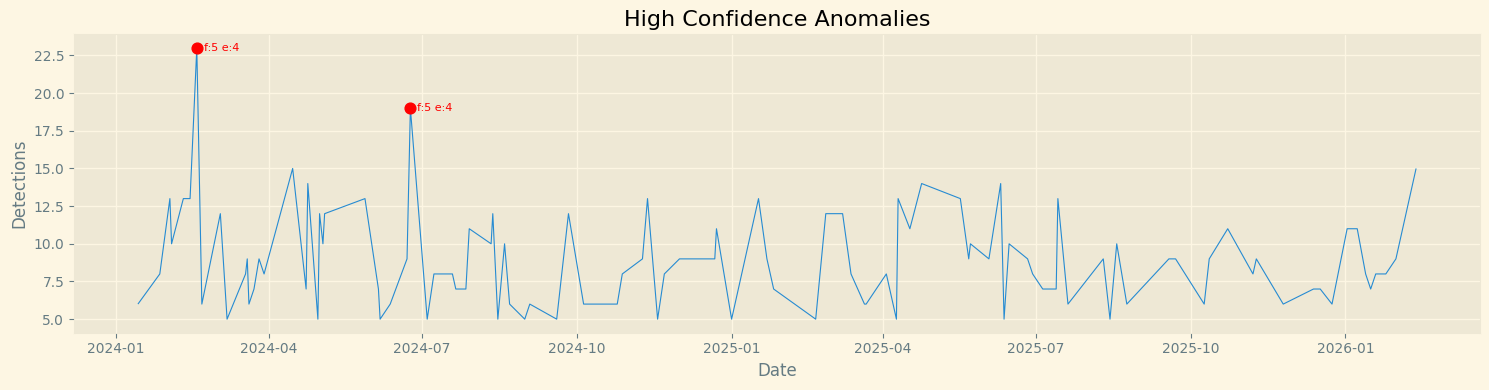

In [111]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(s_raw.index, s_raw.values, linewidth=0.8)

for date, row in high_confidence.iterrows():
    ax.scatter(date, s_raw.loc[date], color="red", s=60, zorder=5)
    ax.text(date, s_raw.loc[date],
            f"  f:{int(row['filtered_count'])} e:{int(row['excluded_count'])}",
            color="red", fontsize=8, va="center")

ax.set_title("High Confidence Anomalies")
ax.set_xlabel("Date")
ax.set_ylabel("Detections")
plt.tight_layout()
plt.show()

---  
### ClassicSeasonalDecomposition

In [112]:
from adtk.transformer import ClassicSeasonalDecomposition

In [113]:
s_transformed = (
    ClassicSeasonalDecomposition(freq=7)
    .fit_transform(s)
    .loc[real_index]
    .rename("Seasonal decomposition residual and trend")
)

array([<Axes: >, <Axes: >], dtype=object)

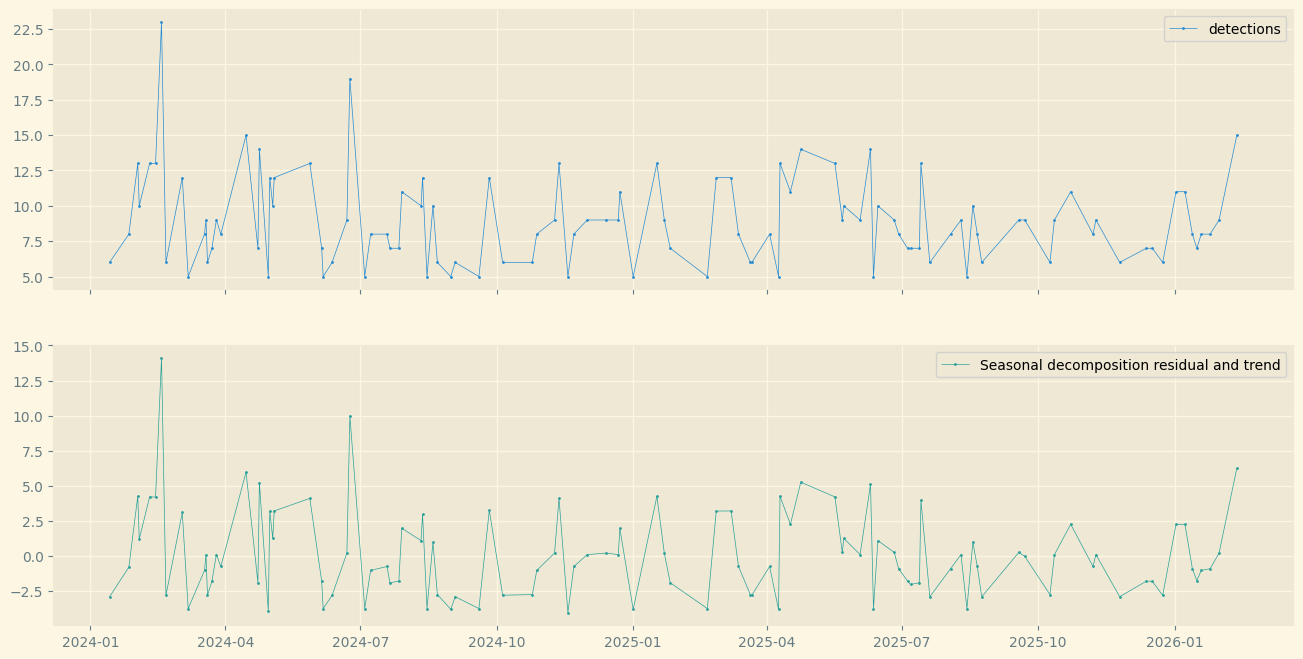

In [114]:
plot(pd.concat([s_raw, s_transformed], axis=1))